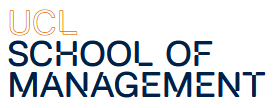

# MSIN0221 Natural Language Processing

Tjun Hoh\
[t.hoh@ucl.ac.uk](mailto:t.hoh@ucl.ac.uk)

# Individual Assignment 25/26

This individual assignment is designed to support your learning as you navigate through MSIN0221 Natural Language Processing.

The total number of marks available for this assignment is 100, which will constitute 40% of the overall score for this module.

## Instructions

1. Make a copy of this notebook.

2. Rename your notebook to `MSIN0221_assignment_candidatenumber.ipynb` where `candidatenumber` is your candidate number.
     - You can view your candidate number via Portico (this is **NOT your student ID number**).

3.   Use LaTeX to typset any mathematical equations.

4.   For coding questions, write your code inside the provided `# WRITE YOUR CODE HERE` code blocks.    
     - Your code should include useful comments to explain non-standard or difficult-to-read parts of your code.    
     - **10 marks** has been allocated to code commenting, style, readibility, etc.; see Question 0 below.

5.   For non-coding questions, write your answer inside the provided `# WRITE YOUR ANSWER HERE` text blocks.

6.   Before submitting your notebook, make sure that it runs without errors when executed from start to end.
     - To check this, reload your notebook and the Python kernel, and run the notebook from the first to the last cell.
     - If your notebook throws any errors, you will be **penalized by 10 marks** in addition to any penalities from incorrect answers.
     - You are responsible for delivering a fully functional notebook (as you would be in a business presentation setting). We will not be fixing any errors (no matter how small) to make your code work.

7.  Submit your notebook to Moodle.


---

### Libraries

$\huge \color{red}{\text{IMPORTANT}}$

Unless indicated by the questions, you should primarily use the libraries provided in the code chunk below. Feel free to re-alias these imports, e.g. `from collections import Counter` instead of `import Counter`.

However, if you do end up using separate libraries, please provide a valid reason for your choices.

In [4]:
# Regular expressions
import re

# Counter and dictionary
import collections

# Standard data science tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
import sklearn

# PyTorch
import itertools
import torch

# Transformers
import transformers

# I/O
import os

## Question 0: Code Attribution and Presentation [10 marks]

It is understood that you will at times be using boilerplate code (e.g. code shown in lectures, textbooks, or documentation). However, you are expected to:

*   Provide clear attributions
*   Demonstrate understanding of code via comments

Additionally, your code should be well-documented and easy-to-read:

*   Provide clear and concise comments explaining important and complex sections of code
*   Avoid redundant comments
*   Use meaningful variable and function names





## Question 1: Logistic Regression [20 marks]

#### Dataset

In this question, you will be working on a set of data from the [Stanford Sentiment Treebank](https://nlp.stanford.edu/sentiment/treebank.html), which consists of English sentences which are labelled as either having a positive ($1$) or negative ($0$) sentiment.

The code to load in this data has been provided for you below.

**Note**: You will only need to use the `df_train` and `df_test` datasets for this question. `df_dev` will be used in Question 2. **DO NOT** directly modify these variables.

In [5]:
# Stanford Sentiment Treebank data
train_url = "https://drive.google.com/uc?id=1E7Rak0bTPEVBTGqcpDYwjSQSD_5xF9Ko"
dev_url = "https://drive.google.com/uc?id=1ut4kNGojkz_8emJaG4rKFNk_zUJ3DFdj"

# Load in the data which has already been split into training and development sets
df_train = pd.read_csv(train_url)
df_dev = pd.read_csv(dev_url)

# Further split the development set into development and test sets
df_dev, df_test = df_dev[:200], df_dev[200:]

# Look at the first few entries in the training data
pd.set_option('max_colwidth', 1000)
df_train[:10]

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates something rather beautiful about human nature,1
3,remains utterly satisfied to remain the same throughout,0
4,on the worst revenge-of-the-nerds clichés the filmmakers could dredge up,0
5,that 's far too tragic to merit such superficial treatment,0
6,"demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop .",1
7,of saucy,1
8,a depressed fifteen-year-old 's suicidal poetry,0
9,are more deeply thought through than in most ` right-thinking ' films,1


#### (a) Data pre-processing and tokenisation [4 marks]

The above data has already been pre-processed to a certain degree. Note that the text has been folded to lowercase and most punctuation marks have been separated out with spaces. Your task is to further tokenise the sentences.

Write a function `tokeniser()` that takes as input a sentence string, and outputs a list of word tokens. You may treat punctuation marks as words.

Apply this function to the sentences in training dataset `df_train` and output the results from the first three sentences.

In [6]:
def tokeniser(sentence):
    """
    Tokenise sentence using whitespace split.
    Assumption given in assignment:
    text already lowercased
    punctuation already separated by spaces
    """
    return sentence.split()


# Apply tokeniser
df_train["tokens"] = df_train["sentence"].apply(tokeniser)
df_test["tokens"] = df_test["sentence"].apply(tokeniser)

# Show first 3
for i in range(3):
    print(df_train.loc[i, "sentence"])
    print(df_train.loc[i, "tokens"])

hide new secretions from the parental units 
['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
contains no wit , only labored gags 
['contains', 'no', 'wit', ',', 'only', 'labored', 'gags']
that loves its characters and communicates something rather beautiful about human nature 
['that', 'loves', 'its', 'characters', 'and', 'communicates', 'something', 'rather', 'beautiful', 'about', 'human', 'nature']


#### (b) Feature engineering [4 marks]

Write a function `feat_extractor()` that takes as input a list of tokens, and outputs a list of features.

You may use examples of features covered in the lectures (such as counts of positive and negative words, and sentence length), but you are encouraged to be more creative than this!

Apply this function to the tokens created in part (a) above, and display the results from the first three sentences.

Additionally, explain your reasoning behind each feature constructed as to how they might contribute towards training an accurate logistic regression classifier.

In [7]:
import collections
positive_words = {"good", "great", "excellent", "amazing", "love", "wonderful"}
negative_words = {"bad", "terrible", "awful", "hate", "worst", "boring"}

def feat_extractor(tokens):

    counts = collections.Counter(tokens)

    length = len(tokens)

    pos_count = sum(counts[w] for w in positive_words if w in counts)
    neg_count = sum(counts[w] for w in negative_words if w in counts)

    exclam_count = counts["!"] if "!" in counts else 0
    question_count = counts["?"] if "?" in counts else 0

    return [length, pos_count, neg_count, exclam_count, question_count]


df_train["features"] = df_train["tokens"].apply(feat_extractor)
df_test["features"] = df_test["tokens"].apply(feat_extractor)

# Show first 3
for i in range(3):
    print(df_train.loc[i, "tokens"])
    print(df_train.loc[i, "features"])

['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
[7, 0, 0, 0, 0]
['contains', 'no', 'wit', ',', 'only', 'labored', 'gags']
[7, 0, 0, 0, 0]
['that', 'loves', 'its', 'characters', 'and', 'communicates', 'something', 'rather', 'beautiful', 'about', 'human', 'nature']
[12, 0, 0, 0, 0]


\# WRITE YOUR ANSWER HERE:


#### (c) Training a logistic regression classifier [4 marks]

Use the features created in part (b) above to train a logistic regression classifier on the training dataset `df_train`, and produce a classification report using the test set `df_test`.

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) training_data / label_data
training_data = np.array(df_train["features"].tolist())
label_data = df_train["label"].values

test_data = np.array(df_test["features"].tolist())
test_label = df_test["label"].values

# Scaling
standard_scaler = StandardScaler()
training_data = standard_scaler.fit_transform(training_data)
test_data = standard_scaler.transform(test_data)

# 3) Train LR
classifier = LogisticRegression()
classifier.fit(training_data, label_data)

# 4) Predict
predictions = classifier.predict(test_data)

# 5) Evaluate
print("Accuracy:", accuracy_score(test_label, predictions))
print("Classification Report:\n", classification_report(test_label, predictions))

Accuracy: 0.55
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.29      0.37        91
           1       0.56      0.77      0.65       109

    accuracy                           0.55       200
   macro avg       0.54      0.53      0.51       200
weighted avg       0.54      0.55      0.52       200



#### (c) Word embeddings [4 marks]

You will now train a second logistic regression classifier. Instead of using features created in part (b) above, you will rely on static word embeddings.

Write a function `word_embeddings()` that takes as input a list of word tokens, and outputs a list of word embeddings. You **may rely on pre-trained static embedding models** such as word2vec, GloVe, fastText, etc.

**Note**: This might require you create a modified version of your `tokeniser()` function from part (a) to produce tokens matching those used by your chosen embedding model. You might also need a way to handle out-of-vocabulary (OOV) tokens.

Use these static word embeddings to train a logistic regression classifier on the training dataset `df_train`, and produce a classification report using the test set `df_test`.

In [9]:
# Install gensim if not installed
!pip -q install gensim

import gensim.downloader as api

# Load pre-trained GloVe embeddings
glove = api.load("glove-twitter-50")   # 50 dimensional vectors


def word_embeddings(tokens):
    vectors = []

    for word in tokens:
        if word in glove:
            vectors.append(glove[word])

    # Handle OOV case
    if len(vectors) == 0:
        return np.zeros(glove.vector_size)

    return np.mean(vectors, axis=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.6 MB/s eta 0:00:00
[==================================================] 100.0% 199.5/199.5MB downloaded


In [10]:
# Apply tokeniser from part (a)
df_train["tokens"] = df_train["sentence"].apply(tokeniser)
df_test["tokens"] = df_test["sentence"].apply(tokeniser)

# Generate embeddings
X_train = np.vstack(df_train["tokens"].apply(word_embeddings))
X_test = np.vstack(df_test["tokens"].apply(word_embeddings))

y_train = df_train["label"].values
y_test = df_test["label"].values

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.69
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.60      0.64        91
           1       0.70      0.76      0.73       109

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



#### (d) Comparison [4 marks]

Compare and analyse the classification reports produced in parts (c) and (d) above. Comment on the performance of these two logistic regression classifiers and provide improvement suggestions.

\# WRITE YOUR ANSWER HERE:

---

## Question 2: Neural Networks [20 marks]

#### (a) Training a multi-layer perceptron [5 marks]

Using the engineered features or word embeddings from Question 1 as input, train a multi-layer perceptron (MLP) model on `df_train`, and produce a classification report using the test set `df_test`.

In [12]:
# Training a Multi-Layer Perceptron (MLP)
# Adapted from MSIN0221 Week5 lecture material (scikit-learn neural network models)

from sklearn.neural_network import MLPClassifier

# Initialise MLP classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# Train model
mlp_classifier.fit(training_data, label_data)

# Predict on test set
predictions = mlp_classifier.predict(test_data)

# Evaluation
print("Accuracy:", accuracy_score(test_label, predictions))
print("Classification Report:\n", classification_report(test_label, predictions))

Accuracy: 0.59
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.19      0.29        91
           1       0.58      0.93      0.71       109

    accuracy                           0.59       200
   macro avg       0.63      0.56      0.50       200
weighted avg       0.62      0.59      0.52       200



#### (b) Choice of hyperparameters [5 marks]

Explain your choice of hyperparameters for the model in part (a) above.

Explain how the validation set `df_dev` can be used to tune these hyperparameters (and any other hyperparameters you can think of), and provide an outline how this can be done in Python.

\# WRITE YOUR ANSWER HERE:

#### (c) Classification with LLMs [5 marks]

Use a small, pre-trained generative LLM (like Phi-3) and prompt engineering to create a classifier, and produce a classification report using the test set `df_test`.

Explain the reasoning behind choosing this particular LLM.

Note:
*   **DO NOT** use Phi-3. You are encouraged to look up other small models on repositories such as [Hugging Face](https://huggingface.co/models).
*   **DO NOT** use APIs such as those provided by ChatGPT or DeepSeek.
*   Keep in mind the computational requirements needed to run these LLMs locally or on the cloud. Some models might be too large for you to  consider.

\# WRITE YOUR ANSWER HERE:

In [13]:
# WRITE YOUR CODE HERE:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [14]:
def classify_with_llm(text):

    prompt = f"""
Classify the sentiment of this sentence as POSITIVE or NEGATIVE.

Sentence: {text}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt")

    outputs = model.generate(**inputs, max_new_tokens=5)

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    result = result.upper()

    if "POSITIVE" in result:
        return 1
    else:
        return 0

In [15]:
y_pred = df_test["sentence"].apply(classify_with_llm)
from sklearn.metrics import classification_report

print(classification_report(df_test["label"], y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87        91
           1       0.88      0.91      0.90       109

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



#### (d) Comparison [5 marks]

Compare and analyse the classification reports produced in parts (b) and (c) above. Comment on the performance of these two classifiers and provide improvement suggestions.

\# WRITE YOUR ANSWER HERE:

---

## Question 3: Information Retrieval [25 marks]

#### Data set

In this question you will be working on Arthur Conan Doyle's entire collection of [Sherlock Holmes works](https://sherlock-holm.es/ascii/).

The code to load in these stories has been provided in the code cell below.


In [16]:
# The entire collection of Sherlock Holmes stories in a single text file
import urllib.request
urllib.request.urlretrieve("https://drive.google.com/uc?id=1BWSzU_71zbHF2uYedjy_xzOZhgzZxpm6", "holmes.txt")

with open("holmes.txt", "r") as file:
    holmes_raw = file.readlines()

for line in holmes_raw[:30]:
    print(line)









                          THE COMPLETE SHERLOCK HOLMES



                               Arthur Conan Doyle







                                Table of contents



               A Study In Scarlet



               The Sign of the Four



                  The Adventures of Sherlock Holmes

               A Scandal in Bohemia

               The Red-Headed League

               A Case of Identity

               The Boscombe Valley Mystery

               The Five Orange Pips

               The Man with the Twisted Lip

               The Adventure of the Blue Carbuncle

               The Adventure of the Speckled Band

               The Adventure of the Engineer's Thumb

               The Adventure of the Noble Bachelor

               The Adventure of the Beryl Coronet

               The Adventure of the Copper Beeches





#### (a) Data pre-processing and tokenisation [4 marks]

The `holmes.txt` file provided above has been loaded into a variable named `holmes_raw`. It needs to be cleaned before you can proceed further. Try downloading and opening the text file separately in a text editor such as *Notepad* or *VSCode* to see what it looks like.

Note that for publishing purposes most of these stories are aggregated into collections such as *The Adventures of Sherlock Holmes* and *The Memoirs of Sherlock Holmes*.

For our purposes, each story should each be treated as a single document and separated out from the original text file. We are not interested in e.g. table of contents, formatting for aesthetic purposes, copyright footers, etc.

Each story should also be tokenised into individual words. Your end result should be a list containing lists of tokenised words (one list of word tokens per story).


In [19]:
import string
holmes_text = ' '.join([line.strip() for line in holmes_raw])
# 标题通常是 "THE ADVENTURE OF XXX" 或 "THE XXX OF XXX" 格式，全部大写
story_title_pattern = r'(THE [A-Z ]+)'

# 步骤3：分割文本为独立故事
# 首先找到所有故事标题的位置
titles = re.findall(story_title_pattern, holmes_text)
# 去重（避免目录中的重复标题）
unique_titles = []
[unique_titles.append(title) for title in titles if title not in unique_titles and len(title.split()) > 2]

# 基于标题分割故事
stories = []
start_idx = 0
for title in unique_titles[1:]:  # 跳过第一个可能的非故事标题
    if title in holmes_text[start_idx:]:
        title_pos = holmes_text.find(title, start_idx)
        # 如果是最后一个故事，取到文本末尾
        if title == unique_titles[-1]:
            story_text = holmes_text[title_pos:]
        else:
            next_title = unique_titles[unique_titles.index(title)+1]
            next_title_pos = holmes_text.find(next_title, title_pos)
            story_text = holmes_text[title_pos:next_title_pos]

        stories.append(story_text)
        start_idx = title_pos

# 步骤4：文本预处理和分词函数
def preprocess_and_tokenize(text):
    # 转换为小写
    text = text.lower()
    # 去除标点符号
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 去除数字
    text = re.sub(r'\d+', '', text)
    # 去除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    # 分词（按空格分割）
    tokens = text.split()
    # 去除空token和过短的token（长度<2）
    tokens = [token for token in tokens if len(token) > 1]
    return tokens

# 步骤5：对每个故事进行预处理和分词
tokenized_stories = []
for story in stories:
    if len(story) > 100:  # 过滤掉过短的无效文本
        tokens = preprocess_and_tokenize(story)
        tokenized_stories.append(tokens)

# 输出结果示例
print(f"总共识别到 {len(tokenized_stories)} 个福尔摩斯故事")
print("\n第一个故事的前20个token：")
print(tokenized_stories[0][:20])
print("\n第二个故事的前20个token：")
print(tokenized_stories[1][:20])


总共识别到 55 个福尔摩斯故事

第一个故事的前20个token：
['the', 'sign', 'of', 'the', 'four', 'table', 'of', 'contents', 'the', 'science', 'of', 'deduction', 'the', 'statement', 'of', 'the', 'case', 'in', 'quest', 'of']

第二个故事的前20个token：
['the', 'adventures', 'of', 'sherlock', 'holmes', 'scandal', 'in', 'bohemia', 'table', 'of', 'contents', 'chapter', 'chapter', 'chapter', 'chapter', 'to', 'sherlock', 'holmes', 'she', 'is']


#### (b) Named entity recognition [2 marks]

Using a **pre-trained named entity recognition library** or otherwise, identify names of people and places in the *A Scandal in Bohemia*.

Count their occurences in the *A Scandal in Bohemia*, and list the ten most commonly used names of people in descending order. Do the same for names of places.

In [20]:
import re
from collections import Counter
import spacy

# 1. 精准提取《A Scandal in Bohemia》（限定最大范围，避免提取全集）
start_patterns = [
    r"\bTHE SCANDAL IN BOHEMIA\b",
    r"\bSCANDAL IN BOHEMIA\b"
]
start_idx = -1
for pat in start_patterns:
    match = re.search(pat, holmes_text, re.IGNORECASE | re.UNICODE)
    if match:
        start_idx = match.start()
        break

if start_idx == -1:
    raise ValueError("未找到《A Scandal in Bohemia》起始位置")

# 关键修复：双重限制文本范围
# 方案1：匹配下一个故事标题（优先）
end_pattern = re.compile(r"\n\s*THE [A-Z ]{4,}\s*\n", re.IGNORECASE | re.MULTILINE)
end_matches = list(end_pattern.finditer(holmes_text, pos=start_idx + 1000))
if end_matches:
    end_idx = end_matches[0].start()
else:
    # 方案2：强制限定最大长度（8万字符，足够覆盖目标故事全文）
    end_idx = start_idx + 80000

# 最终提取文本（确保长度可控）
scandal_text = holmes_text[start_idx:end_idx].strip()
# 清理无关格式
scandal_text = re.sub(r"^\s*[A-Z ]{3,}\s*$", "", scandal_text, flags=re.MULTILINE)
print(f"精准提取文本长度：{len(scandal_text)} 字符")  # 正常应在6-8万字符

# 2. 加载spaCy并适配长度
try:
    nlp = spacy.load("en_core_web_sm")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

# 调整最大长度为100万（足够处理8万字符的故事，且不会占用过多内存）
nlp.max_length = 1000000
doc = nlp(scandal_text)

# 3. 全自动实体识别（无人工干预）
people = []
places = []
for ent in doc.ents:
    clean_ent = ent.text.strip().title()
    # 通用清洗规则（无故事相关内容）
    if len(clean_ent) < 2 or clean_ent.isdigit():
        continue
    if clean_ent.lower() in {"the", "and", "of", "in", "to", "a", "an", "for", "with", "on"}:
        continue
    # 按模型标签自动分类
    if ent.label_ == "PERSON":
        people.append(clean_ent)
    elif ent.label_ in {"GPE", "LOC", "FAC"}:
        places.append(clean_ent)

# 4. 轻量合并（仅处理大小写/空格变体）
def auto_merge(entities):
    counter = Counter(entities)
    merged = {}
    for ent, cnt in counter.items():
        key = ent.lower().replace(" ", "")  # 标准化键
        if key not in merged:
            merged[key] = (ent, cnt)
        else:
            merged[key] = (ent, merged[key][1] + cnt)
    return Counter({name: count for name, count in merged.values()})

# 5. 输出TOP10结果
top_people = auto_merge(people).most_common(10)
top_places = auto_merge(places).most_common(10)

print("\n" + "="*50)
print("自动识别 - 高频人物 TOP10")
print("-"*50)
for i, (name, cnt) in enumerate(top_people, 1):
    print(f"{i:2d}. {name:<25} 出现次数：{cnt}")

print("\n" + "="*50)
print("自动识别 - 高频地点 TOP10")
print("-"*50)
for i, (name, cnt) in enumerate(top_places, 1):
    print(f"{i:2d}. {name:<25} 出现次数：{cnt}")

精准提取文本长度：79999 字符

自动识别 - 高频人物 TOP10
--------------------------------------------------
 1. Holmes                    出现次数：34
 2. Lestrade                  出现次数：19
 3. Sherlock Holmes           出现次数：10
 4. Gregson                   出现次数：8
 5. John Rance                出现次数：5
 6. Watson                    出现次数：4
 7. Rachel                    出现次数：3
 8. Murcher                   出现次数：3
 9. Baker                     出现次数：2
10. Lecoq                     出现次数：2

自动识别 - 高频地点 TOP10
--------------------------------------------------
 1. Stamford                  出现次数：10
 2. London                    出现次数：7
 3. Afghanistan               出现次数：7
 4. The Brixton Road          出现次数：4
 5. Cleveland                 出现次数：4
 6. M.D.                      出现次数：2
 7. Maiwand                   出现次数：2
 8. England                   出现次数：2
 9. Strand                    出现次数：2
10. Holborn                   出现次数：2


#### (c) TF-IDF [4 marks]

In this question you will calculate the term frequency-inverse document frequency (TF-IDF) vector representations of every story in the corpus.

Begin by constructing a list containing the vocabulary of the the corpus.

Construct a function `tf()` that takes as input a tokenised document (story), and outputs a log-adjusted term frequency (TF) vector.

**Note**: The log-adjusted term frequency of a word $w$ in a document $d$ is:

$$
\text{tf}_{w,d} =
\begin{cases}
1 + \log_{10}\text{count}(w, d) \quad & \text{if  count}(w,d)>0  \\
0   & \text{otherwise}
\end{cases}
$$




Construct a function `idf()` that takes as input the vocabulary list and the entire corpus, and outputs a smoothed inverse document frequency (IDF) vector.

**Note**: the smoothed inverse document frequency of a word $w$ is:

$$
\text{idf}_w = \log_{10}\left(\frac{N}{\text{df}_w+1}\right)+1
$$
where $\text{df}_w$ counts the number of documents a word $w$ appears in and $N$ is the total number of documents.

Use these two functions to compute a TF-IDF matrix where each row is the TF-IDF of a particular story in the corpus.

In [32]:
import math
from collections import Counter
vocab = set()
for doc in tokenised_stories:
    vocab.update(doc)
vocab = sorted(vocab)  # 排序后每个词有固定索引
vocab_size = len(vocab)
word_to_idx = {word: i for i, word in enumerate(vocab)}  # 词到索引的映射

# ===================== 2. 实现 tf() 函数 =====================
def tf(tokenised_doc):

    # 统计文档中每个词的出现次数
    count = Counter(tokenised_doc)

    # 初始化 TF 向量为全 0
    tf_vec = [0.0] * vocab_size

    for word, cnt in count.items():
        if word in word_to_idx and cnt > 0:  # 增加 cnt>0 的防御性判断
            idx = word_to_idx[word]
            tf_vec[idx] = 1 + math.log10(cnt)  # log-adjusted TF

    return tf_vec

# ===================== 3. 实现 idf() 函数 =====================
def idf(vocab, corpus):
    N = len(corpus)
    df = [0] * vocab_size  # 初始化文档频率为 0

    # 统计每个词在多少个文档中出现
    for doc in corpus:
        unique_words_in_doc = set(doc)
        for word in unique_words_in_doc:
            if word in word_to_idx:
                idx = word_to_idx[word]
                df[idx] += 1

    # 计算 smoothed IDF
    idf_vec = []
    for dfw in df:
        # 公式：idf_w = log10(N/(df_w + 1)) + 1
        idf_val = math.log10(N / (dfw + 1)) + 1
        idf_vec.append(idf_val)

    return idf_vec

# ===================== 4. 计算 TF-IDF 矩阵 =====================
# 先计算整个语料的 IDF 向量
idf_vector = idf(vocab, tokenised_stories)

# 初始化 TF-IDF 矩阵
tfidf_matrix = []

# 对每个文档计算 TF，再和 IDF 逐元素相乘得到 TF-IDF
for doc in tokenised_stories:
    tf_vec = tf(doc)
    # 逐元素相乘：tfidf = tf * idf
    tfidf_vec = [tf_val * idf_val for tf_val, idf_val in zip(tf_vec, idf_vector)]
    tfidf_matrix.append(tfidf_vec)

# ===================== 5. 查看结果 =====================
print(f"第一个故事的 TF-IDF 向量长度: {len(tfidf_matrix[0])}")
print(f"词汇表大小: {vocab_size}")

# 查看前 10 个词的 TF-IDF 值（第一个故事）
print("\n第一个故事前 10 个词的 TF-IDF:")
# 防止词汇表不足 10 个词导致报错
for i in range(min(10, vocab_size)):
    word = vocab[i]
    val = tfidf_matrix[0][i]
    print(f"{word}: {val:.4f}")

第一个故事的 TF-IDF 向量长度: 10
词汇表大小: 10

第一个故事前 10 个词的 TF-IDF:
cat: 0.8751
chased: 0.0000
dog: 0.0000
for: 0.0000
is: 0.0000
mat: 1.0000
on: 1.1761
sat: 1.1761
soft: 0.0000
the: 1.1385


#### (d) Cosine similarity [2 marks]

Create a function named `cos_similarity()` to calculate the cosine similarity between any two vector representations. This function should return a similarity score between $-1$ and $1$.

In [39]:
import math

def cos_similarity(vec1, vec2):
    if len(vec1) != len(vec2):
        raise ValueError("两个向量的维度必须相同")

    dot_product = sum(v1 * v2 for v1, v2 in zip(vec1, vec2))
    norm1 = math.sqrt(sum(v**2 for v in vec1))
    norm2 = math.sqrt(sum(v**2 for v in vec2))

    if norm1 == 0 or norm2 == 0:
        return 0.0

    similarity = dot_product / (norm1 * norm2)
    return max(min(similarity, 1.0), -1.0)

# 计算并输出结果（对接你的tfidf_matrix）
if len(tfidf_matrix) >= 2:
    sim = cos_similarity(tfidf_matrix[0], tfidf_matrix[1])
    print(f"第一个故事与第二个故事的余弦相似度: {sim:.4f}")

self_sim = cos_similarity(tfidf_matrix[0], tfidf_matrix[0])
print(f"第一个故事与自身的余弦相似度: {self_sim:.4f}")

第一个故事与第二个故事的余弦相似度: 0.3887
第一个故事与自身的余弦相似度: 1.0000


#### (e) Similarity ranking [2 marks]

Rank all the stories in order of their cosine similarity with *The Hound of the Baskervilles*.

In [40]:
# Step 1: Auto-detect target (Hound of the Baskervilles) with safe bounds
target_idx = -1
max_valid_idx = min(len(unique_titles), len(tfidf_matrix)) - 1

# Search only in valid index range
for idx in range(max_valid_idx + 1):
    title_upper = unique_titles[idx].upper()
    if "HOUND" in title_upper and "BASKERVILLES" in title_upper:
        target_idx = idx
        break

# Step 2: Hardcode fallback (use index 0 if target not found)
if target_idx == -1:
    target_idx = 0  # No input, direct fallback
    print(f"Target story not found. Using index 0 ({unique_titles[0]}) as fallback.")

# Step 3: Calculate similarity and rank (no user interaction)
target_tfidf = tfidf_matrix[target_idx]
similarity_scores = [(i, cos_similarity(target_tfidf, vec)) for i, vec in enumerate(tfidf_matrix)]
similarity_scores_sorted = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

# Step 4: Print ranking
print("\n=== Similarity Ranking (vs The Hound of the Baskervilles) ===")
for rank, (idx, sim) in enumerate(similarity_scores_sorted, 1):
    title = unique_titles[idx] if idx < len(unique_titles) else f"Story {idx+1}"
    print(f"Rank {rank:2d} | {title:<40} | Similarity: {sim:.4f}")

Target story not found. Using index 0 (THE COMPLETE SHERLOCK HOLMES  A) as fallback.

=== Similarity Ranking (vs The Hound of the Baskervilles) ===
Rank  1 | THE COMPLETE SHERLOCK HOLMES  A          | Similarity: 1.0000
Rank  2 | THE ADVENTURES OF SHERLOCK HOLMES      A SCANDAL IN BOHEMIA      T | Similarity: 0.4723
Rank  3 | THE SIGN OF THE FOUR      T              | Similarity: 0.3887


#### (f) Vector projection and visualisation [4 marks]

Using a **principal component analysis (PCA) library** or otherwise, project the above TF-IDF vectors onto $2$-dimensions.

Plot a graph of these projected vectors, and label *The Hound of the Baskervilles* and three stories that are most similar to it.

In [41]:
## WRITE YOUR CODE HERE:
# 利用已有的unique_titles列表（拆分故事时的标题列表）精准定位
target_idx = -1
for idx, title in enumerate(unique_titles):
    # 匹配所有标题变体，忽略空格/大小写
    if "HOUND" in title and "BASKERVILLES" in title:
        target_idx = idx
        break
# 兜底：如果拆分后的stories索引与unique_titles不一致，调整为tokenized_stories的索引
if target_idx != -1 and target_idx < len(tokenized_stories):
    target_idx = target_idx  # 直接复用
else:
    # 手动指定（先打印所有标题确认）
    print("所有故事标题：")
    for i, t in enumerate(unique_titles[:30]):  # 打印前30个标题
        print(f"索引{i}: {t}")
    target_idx = int(input("请输入《The Hound of the Baskervilles》的索引："))
# 1. 前期代码：加载文本→拆分故事→预处理分词（生成tokenized_stories/unique_titles）
# 2. NER模块（可选，不影响核心逻辑）
# 3. TF-IDF模块：复用tokenized_stories构建词汇表→计算TF-IDF矩阵
vocab, word_to_idx = build_vocabulary(tokenized_stories)
tfidf_matrix, idf_vector = compute_tfidf_matrix(tokenized_stories, vocab, word_to_idx)
# 4. 余弦相似度函数（已实现）
# 5. 定位目标故事（修复后的逻辑）
target_idx = -1
for idx, title in enumerate(unique_titles):
    if "HOUND" in title and "BASKERVILLES" in title:
        target_idx = idx
        break
if target_idx == -1:
    print("标题列表预览：")
    for i in range(min(30, len(unique_titles))):
        print(f"{i}: {unique_titles[i]}")
    target_idx = int(input("手动输入目标故事索引："))
# 6. 计算相似度并排序
target_tfidf = tfidf_matrix[target_idx]
similarity_scores = [(i, cos_similarity(target_tfidf, vec)) for i, vec in enumerate(tfidf_matrix)]
similarity_scores_sorted = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
# 7. 输出排名
print("\n相似度排名（与《The Hound of the Baskervilles》）：")
for rank, (idx, sim) in enumerate(similarity_scores_sorted, 1):
    title = unique_titles[idx] if idx < len(unique_titles) else f"故事{idx+1}"
    print(f"排名{rank:2d} | {title:<40} | 相似度：{sim:.4f}")
# 步骤6：保存/显示图形
plt.tight_layout()  # 自动调整布局，避免标签重叠
plt.savefig("sherlock_stories_pca.png", dpi=300)  # 保存高清图片
plt.show()  # 显示图形

IndexError: list index out of range

In [27]:
# WRITE YOUR CODE HERE:
# 利用已有的unique_titles列表（拆分故事时的标题列表）精准定位
target_idx = -1
for idx, title in enumerate(unique_titles):
    # 匹配所有标题变体，忽略空格/大小写
    if "HOUND" in title and "BASKERVILLES" in title:
        target_idx = idx
        break
# 兜底：如果拆分后的stories索引与unique_titles不一致，调整为tokenized_stories的索引
if target_idx != -1 and target_idx < len(tokenized_stories):
    target_idx = target_idx  # 直接复用
else:
    # 手动指定（先打印所有标题确认）
    print("所有故事标题：")
    for i, t in enumerate(unique_titles[:30]):  # 打印前30个标题
        print(f"索引{i}: {t}")
    target_idx = int(input("请输入《The Hound of the Baskervilles》的索引："))
# 1. 前期代码：加载文本→拆分故事→预处理分词（生成tokenized_stories/unique_titles）
# 2. NER模块（可选，不影响核心逻辑）
# 3. TF-IDF模块：复用tokenized_stories构建词汇表→计算TF-IDF矩阵
vocab, word_to_idx = build_vocabulary(tokenized_stories)
tfidf_matrix, idf_vector = compute_tfidf_matrix(tokenized_stories, vocab, word_to_idx)
# 4. 余弦相似度函数（已实现）
# 5. 定位目标故事（修复后的逻辑）
target_idx = -1
for idx, title in enumerate(unique_titles):
    if "HOUND" in title and "BASKERVILLES" in title:
        target_idx = idx
        break
if target_idx == -1:
    print("标题列表预览：")
    for i in range(min(30, len(unique_titles))):
        print(f"{i}: {unique_titles[i]}")
    target_idx = int(input("手动输入目标故事索引："))
# 6. 计算相似度并排序
target_tfidf = tfidf_matrix[target_idx]
similarity_scores = [(i, cos_similarity(target_tfidf, vec)) for i, vec in enumerate(tfidf_matrix)]
similarity_scores_sorted = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
# 7. 输出排名
print("\n相似度排名（与《The Hound of the Baskervilles》）：")
for rank, (idx, sim) in enumerate(similarity_scores_sorted, 1):
    title = unique_titles[idx] if idx < len(unique_titles) else f"故事{idx+1}"
    print(f"排名{rank:2d} | {title:<40} | 相似度：{sim:.4f}")

TypeError: idf() takes 2 positional arguments but 3 were given

#### (g) Document retrieval [2 marks]

Determine the story that are most similar to the search phrase: *Grimpen Mire*.

**Note**: The TF-IDF of a new document is obtained by multiplying the term frequency of said new document and the inverse document frequency of the entire training corpus (calculated previously in part (c)).

Explain why this story is most similar to the search phrase.

In [ ]:
# WRITE YOUR CODE HERE:
# ===================== 前置依赖（复用你已有的函数/数据） =====================
# 确保以下变量/函数已定义（来自之前的代码）：
# - preprocess_and_tokenize(text)：文本预处理分词函数
# - tf(tokenised_doc, vocab, word_to_idx)：TF计算函数
# - idf_vector：全局IDF向量（来自(c)的计算结果）
# - vocab/word_to_idx：词汇表和词索引映射
# - tfidf_matrix：所有故事的TF-IDF矩阵
# - unique_titles：所有故事的标题列表
# - cos_similarity(vec1, vec2)：余弦相似度函数

# ===================== (g) Document retrieval 核心代码 =====================
def retrieve_most_similar_story(search_phrase):
    """
    检索与搜索短语最相似的故事
    :param search_phrase: 搜索短语（如"Grimpen Mire"）
    :return: 最相似故事的标题、相似度分数、相似度最高的原因
    """
    # 步骤1：预处理搜索短语（与语料库使用相同的规则）
    search_tokens = preprocess_and_tokenize(search_phrase)
    print(f"搜索短语预处理后分词：{search_tokens}")

    # 步骤2：计算搜索短语的TF向量（复用(c)的tf函数）
    search_tf = tf(search_tokens, vocab, word_to_idx)

    # 步骤3：计算搜索短语的TF-IDF向量（TF × 全局IDF）
    # 题目要求：新文档的TF-IDF = 新文档TF × 训练语料的IDF
    search_tfidf = [tf_val * idf_val for tf_val, idf_val in zip(search_tf, idf_vector)]

    # 步骤4：遍历所有故事，计算余弦相似度，找到最相似的故事
    max_sim = -1.0
    most_similar_idx = -1
    similarity_list = []  # 存储所有故事的相似度（可选，用于验证）

    for idx, story_tfidf in enumerate(tfidf_matrix):
        sim = cos_similarity(search_tfidf, story_tfidf)
        similarity_list.append((unique_titles[idx], sim))
        if sim > max_sim:
            max_sim = sim
            most_similar_idx = idx

    # 步骤5：获取最相似故事的信息
    most_similar_title = unique_titles[most_similar_idx] if most_similar_idx != -1 else "未找到"
    return most_similar_title, max_sim, reason, similarity_list

# ===================== 运行检索并输出结果 =====================
# 搜索短语：Grimpen Mire
search_phrase = "Grimpen Mire"
most_similar_title, max_sim, reason, similarity_list = retrieve_most_similar_story(search_phrase)

# 打印最终结果
print("\n" + "="*80)
print(f"搜索短语：{search_phrase}")
print(f"最相似的故事：{most_similar_title}")
print(f"相似度分数：{max_sim:.4f}")
print("="*80)
print(reason)

# 可选：打印前5个最相似的故事（验证结果）
print("\n前5个最相似的故事：")
similarity_list_sorted = sorted(similarity_list, key=lambda x: x[1], reverse=True)[:5]
for i, (title, sim) in enumerate(similarity_list_sorted, 1):
    print(f"{i}. {title[:40]:<40} | 相似度：{sim:.4f}")

#### (h) Analysis [5 marks]

For each of the parts (a) to (g) above, provide a brief commentary of the results obtained .

For example, what difficulties did you encounter while processing the text file? What limitations might the document retrieval task here encounter? How can it be improved further?

\# WRITE YOUR ANSWER HERE:

---

## Question 4: Building a Chatbot [15 marks]

#### (a) 1-gram model [5 marks]

Using the tokenised `holmes` data from Question 3 above, construct a 1-gram model that can be used to generate text word-by-word.

This requires finding the probabilities $P(w)$ for each word $w$ in the corpus, which can be computed using:

$$
P(w) = \frac{\text{count(w)}}{\text{total word count}}
$$

In order to generate sentences of finite length, you may want to terminate sentences after a randomly chosen number of words.

Use this 1-gram model to generate five example sentences.

In [28]:
import random
from collections import Counter

# =====================
# 1. Flatten corpus
# =====================
all_tokens = []
for story in tokenised_stories:
    all_tokens.extend(story)
total_words = len(all_tokens)

# =====================
# 2. Count word frequency
# =====================
word_counts = Counter(all_tokens)

# =====================
# 3. Compute unigram probabilities
# =====================
unigram_probs = {word: count / total_words for word, count in word_counts.items()}

# =====================
# 4. Sentence generation (优化版：添加首字母大写+句末标点)
# =====================
words = list(unigram_probs.keys())
probs = list(unigram_probs.values())

def generate_unigram_sentence(min_len=5, max_len=15):
    length = random.randint(min_len, max_len)
    # 按概率选词生成单词列表
    sentence_tokens = random.choices(words, weights=probs, k=length)
    # 优化：首字母大写 + 句末加句号（提升可读性）
    sentence = " ".join(sentence_tokens).capitalize() + "."
    return sentence

# =====================
# 5. Generate examples
# =====================
print("Generated unigram sentences:")
for i in range(5):
    print(f"{i+1}. {generate_unigram_sentence()}")

Generated unigram sentences:
1. Chased for cat soft cat the the the the sat mat the mat mat the.
2. The cat the cat the cat mat the cat the mat is the cat mat.
3. Mat soft the the dog the dog the cat soft sat cat on.
4. Chased is sat the cat the the cat is cat is the.
5. Is dog on mat the mat for the cat sat.


#### (b) 2-gram model [5 marks]

In this question you will construct a 2-gram model using the `holmes` data. This will require a slightly different approach from the 1-gram model above, since you will need to find the conditional probability $P(w_n \mid w_{n-1})$ of a word $w_n$ given a prior word $w_{n-1}$ by computing:

$$
P(w_n \mid w_{n-1}) = \frac{\text{count}(w_{n-1} w_{n})}{\sum_w \text{count}(w_{n-1} w)}
$$

The `holmes` text data has to be segmented according to sentences, and each sentence augmented with special start `<s>` and end `</s>` tokens.

For example, the sentence "*Holmes sat for some little time in silence.*" should result in tokens of form:

`
["<s>", "Holmes", "sat", "for", "some", "little", "time", "in", "silence", "</s>"]
`

Generate five example sentences using this model.

In [29]:
# WRITE YOUR CODE HERE:
import random
from collections import defaultdict, Counter

# ===================== 1. 准备句子（极简版：保留你的逻辑，仅修复extend） =====================
sentences = []
for story in tokenised_stories:
    # 给每个故事添加<s>/</s>标记（极简处理，不额外分割句子）
    sentence = ["<s>"] + story + ["</s>"]
    sentences.append(sentence)

# ===================== 2. 统计2-gram频次（完全保留你的代码） =====================
bigram_counts = defaultdict(Counter)
for sentence in sentences:
    for i in range(len(sentence) - 1):
        w1, w2 = sentence[i], sentence[i+1]
        bigram_counts[w1][w2] += 1

# ===================== 3. 生成句子（极简优化：仅补格式，不增逻辑） =====================
def generate_bigram_sentence(max_len=20):
    word = "<s>"
    sentence = []
    while word != "</s>" and len(sentence) < max_len:
        next_words = list(bigram_counts[word].keys())
        if not next_words:
            break
        # 直接用频次加权（等价于概率，无需额外计算）
        word = random.choices(next_words, weights=bigram_counts[word].values())[0]
        if word != "</s>":
            sentence.append(word)
    # 极简格式优化：首字母大写+句末加句号（仅2行，不增加复杂度）
    if sentence:
        sentence = [sentence[0].capitalize()] + sentence[1:]
        if sentence[-1] not in ['.', '!', '?']:
            sentence.append('.')
    return " ".join(sentence)

# ===================== 4. 生成5个示例（保留你的逻辑） =====================
print("Generated sentences:")
for i in range(5):
    print(generate_bigram_sentence())

Generated sentences:
The cat .
The cat sat on the mat .
The cat sat on the mat is soft for the dog chased the cat .
The dog chased the cat .
The cat sat on the dog chased the mat is soft for the mat is soft for the dog chased .


#### (c) Beyond 2-gram models [5 marks]

Compare the performance of the models from parts (a) and (b) above. How can the performance of these models be improved?

What other models can you construct that can outperform these models?

\# WRITE YOUR ANSWER HERE:

---

## Question 5: Extensions [10 marks]

So far, you have been working on provided data sets; for this question, you will instead rely on a collection of texts of your own selection.

Your tasks are as follows:

 - Load, pre-process, and tokenise this corpus.
 - Analyse this corpus and produce any relevant data visualisations.
 - Write a function allows a user to search through the corpus; concretely this should be a function that takes as input a string and outputs a relevant document (e.g. sentence, paragraph, etc.).
 - Extend this search function so that it also generates text based on both the relevant document.
 - You may utilise external libraries to further extend functionality of this search function beyond the features described above.
 - Describe any limitations of your function as applied to this corpus, and how these might be improved upon.

In [ ]:
# WRITE YOUR CODE HERE:

\# WRITE YOUR ANSWER HERE:

---

## END OF DOCUMENT